# Section 1 — Setup and Data Loading

## Academic Theory & Methodology
In supply chain network analytics, the supply chain is modeled as a mathematical graph $G = (V, E)$. The vertex set $V$ represents the entities (suppliers, plants, warehouses, products), and the directed edge set $E$ represents material flows, logistical links, or dependency relationships.

This section imports the necessary numerical computation libraries (`numpy`, `pandas`), graph manipulation libraries (`networkx`), and visualization libraries (`matplotlib`, `seaborn`). We establish a connection to our PostgreSQL database and extract:
1. `suppliers_enriched`: Containing historical supplier performance metrics (average delay days, delay volatility, rejection rate, and a composite reliability score computed in the ETL phase).
2. `products`: The product catalog, including cost structures, monthly demands, and safety stock parameters.
3. `supply_relationships`: The bipartite linkages indicating which suppliers supply which products, and the specific supply share (fraction of demand fulfilled).

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

# Ensure project root is in python path
sys.path.append(os.path.abspath('..'))

# Import custom database and graph utilities
from src.db import get_engine, read_table, read_query, write_dataframe, test_connection
from src.graph import build_dependency_graph, compute_pagerank, compute_centrality_metrics, identify_critical_suppliers, graph_summary

# Set plot styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Test database connectivity
test_connection()

# Load tables into DataFrames
print("Loading tables from PostgreSQL...")
df_suppliers = read_table('suppliers_enriched')
df_products = read_table('products')
df_relationships = read_table('supply_relationships')
print("Data loaded successfully!")
print(f"Suppliers Enriched: {df_suppliers.shape}")
print(f"Products: {df_products.shape}")
print(f"Supply Relationships: {df_relationships.shape}")

Connection SUCCESSful to database 'shockproof' on host 'localhost'.
Loading tables from PostgreSQL...
Data loaded successfully!
Suppliers Enriched: (100, 9)
Products: (500, 8)
Supply Relationships: (1535, 6)


# Section 2 — Graph Construction

## Academic Theory & Graph Representation
A supply chain sourcing structure is naturally modeled as a **directed bipartite network**. In graph theory, a bipartite graph is a graph whose vertices can be divided into two disjoint and independent sets $U$ and $V$ such that every edge connects a vertex in $U$ to one in $V$. 

In our model, the two disjoint sets are:
- Suppliers ($S$): Nodes prefixed with `S_`.
- Products ($P$): Nodes prefixed with `P_`.

Edges only exist from a supplier to a product ($S \to P$), meaning there are no supplier-to-supplier or product-to-product links. Each directed edge $(s, p) \in E$ carries a weight $w(s, p)$ equal to the `supply_share`, representing the proportion of product $p$'s total demand sourced from supplier $s$. Mathematically:
$$\sum_{s \in S} w(s, p) = 1.0 \quad \forall p \in P$$

In this section, we build this dependency graph using NetworkX, print global structural summary statistics (node and edge counts, density, connectivity), and inspect the metadata attributes associated with the nodes.

In [2]:
print("Constructing dependency graph...")
G = build_dependency_graph(df_relationships, df_suppliers, df_products)
print("Graph constructed successfully!")

# Graph summary
print("\n--- Graph Summary ---")
graph_summary(G)

# Print node count and edge count
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print(f"\nExplicit Node Count: {num_nodes}")
print(f"Explicit Edge Count: {num_edges}")

# Show a sample of node attributes for 3 supplier nodes and 3 product nodes
supplier_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'supplier']
product_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'product']

print("\nSample Supplier Nodes Attributes:")
for node in list(supplier_nodes)[:3]:
    print(f"Node {node}: {G.nodes[node]}")
    
print("\nSample Product Nodes Attributes:")
for node in list(product_nodes)[:3]:
    print(f"Node {node}: {G.nodes[node]}")

Constructing dependency graph...
Graph constructed successfully!

--- Graph Summary ---
Total Nodes: 600
Total Edges: 1535
Number of Supplier Nodes: 100
Number of Product Nodes: 500
Average Degree: 5.1167
Density: 0.004271
Is Weakly Connected: True

Top 5 Nodes by PageRank:
  1. Node ID: P_347 (product) - PageRank Score: 0.002326
  2. Node ID: P_400 (product) - PageRank Score: 0.002246
  3. Node ID: P_289 (product) - PageRank Score: 0.002083
  4. Node ID: P_94 (product) - PageRank Score: 0.001933
  5. Node ID: P_478 (product) - PageRank Score: 0.001929

Explicit Node Count: 600
Explicit Edge Count: 1535

Sample Supplier Nodes Attributes:
Node S_1: {'supplier_name': 'Rodriguez, Figueroa and Sanchez (Critical)', 'country': 'Estados Unidos', 'tier': 1, 'reliability_score': 0.65, 'type': 'supplier'}
Node S_2: {'supplier_name': 'Doyle Ltd (geo_cluster)', 'country': 'China', 'tier': 2, 'reliability_score': 0.348, 'type': 'supplier'}
Node S_3: {'supplier_name': 'Mcclain, Miller and Henderson 

# Section 3 — Network Visualisation

## Academic Theory & Visualization Design
Graph visualization is a powerful qualitative tool for diagnosing structural vulnerabilities. To represent the bipartite nature of the supply chain, we implement a custom parallel bipartite layout where supplier nodes are aligned on a vertical axis ($x = 0$) and product nodes are aligned on a parallel vertical axis ($x = 1$).

To optimize information density and readability, we present two visualizations side by side:
1. **Full Network Topology**: Displays the entire bipartite dependency structure. Suppliers are colored by operational tier (Tier 1 is represented in blue, Tier 2 in orange), and products are colored by their category. The edges are scaled in width and colored by `supply_share` (using a blue colormap), highlighting major sourcing channels. The top 10 suppliers by PageRank are explicitly labeled to highlight system bottlenecks.
2. **High-Criticality Subgraph**: Displays a focused projection showing only the top 15 critical suppliers and their directly connected products. The node sizes are scaled proportionally to their PageRank score (structural criticality) to make hubs instantly recognizable, and edges are scaled by supply share, presenting a report-ready diagnostic diagram.

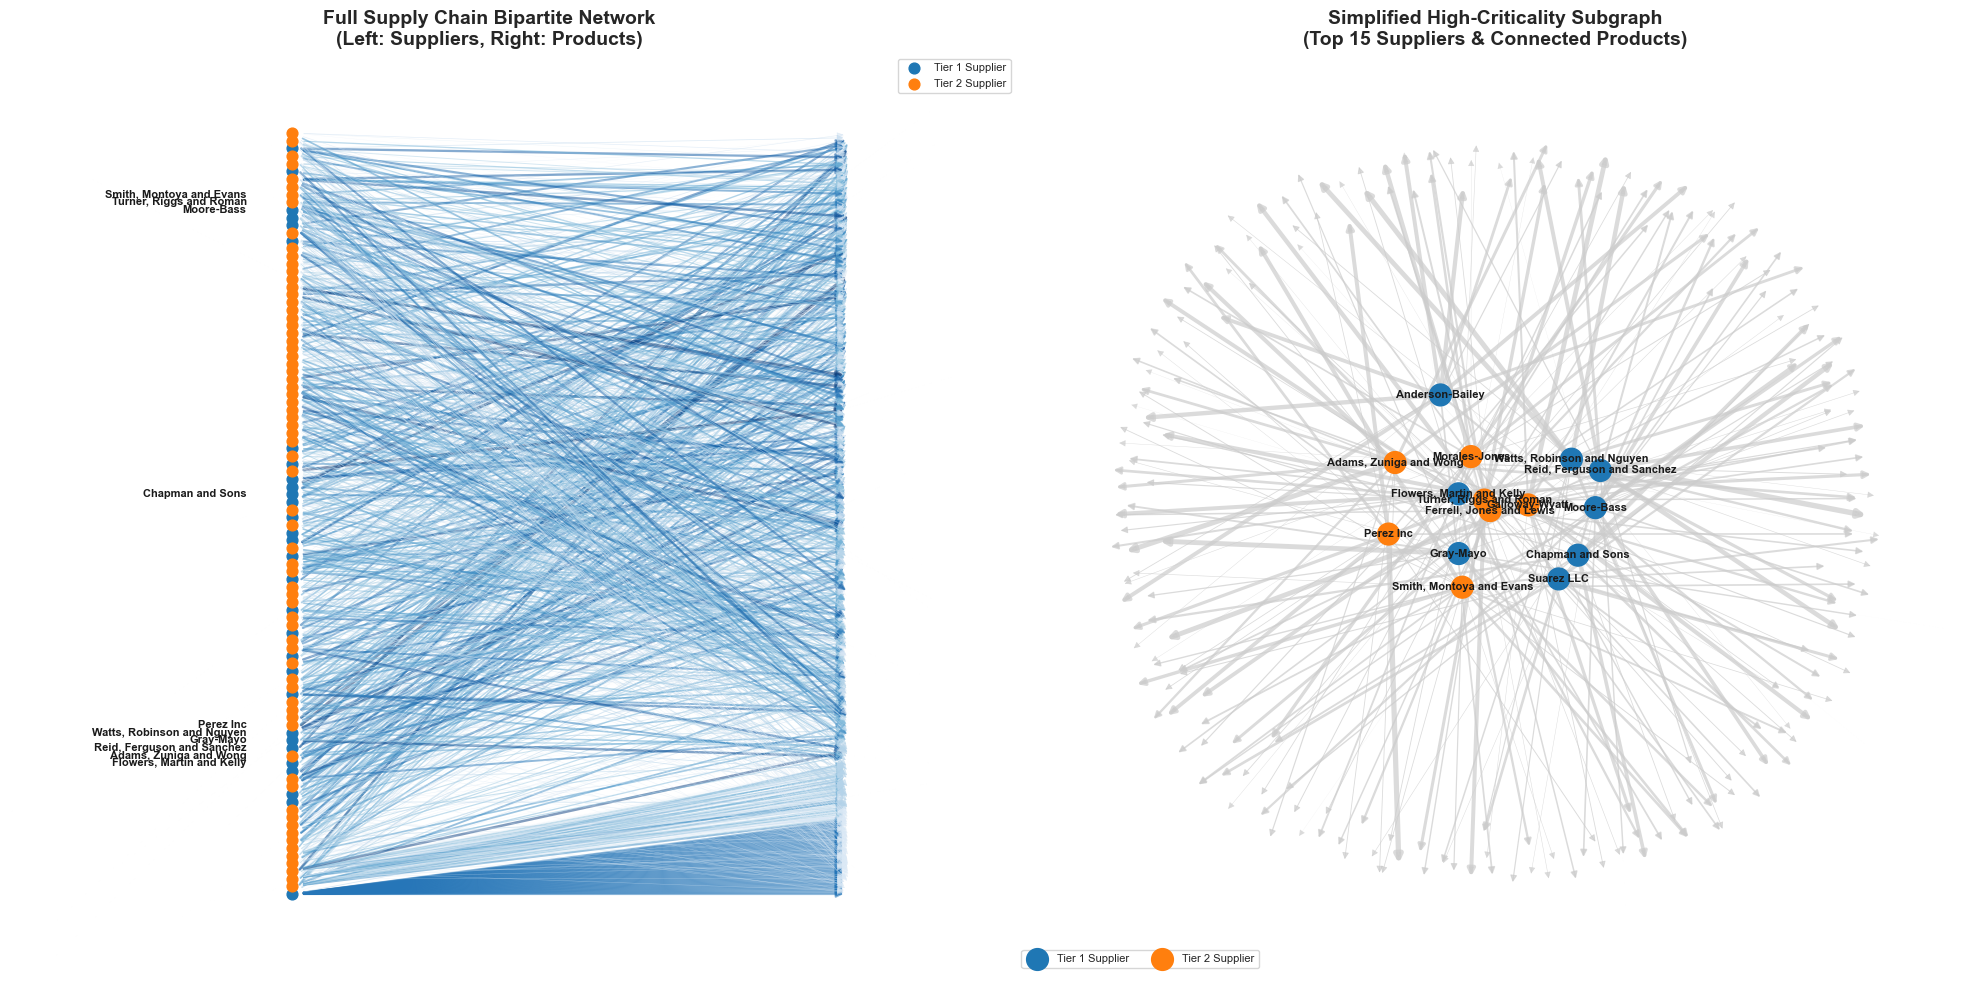

In [3]:
# Compute PageRank and Centrality Metrics beforehand
df_pr = compute_pagerank(G, alpha=0.85)
df_cent = compute_centrality_metrics(G)

# Set up matplotlib figure with side by side subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left subplot: Full Bipartite Graph
ax1 = axes[0]
ax1.set_title("Full Supply Chain Bipartite Network\n(Left: Suppliers, Right: Products)", fontsize=14, fontweight='bold')

# Position nodes: x=0 for suppliers, x=1 for products
pos = {}
sups = sorted([n for n, d in G.nodes(data=True) if d.get('type') == 'supplier'], key=lambda x: int(x.split('_')[1]))
prods = sorted([n for n, d in G.nodes(data=True) if d.get('type') == 'product'], key=lambda x: int(x.split('_')[1]))

for idx, s in enumerate(sups):
    pos[s] = (0.0, idx / max(1, len(sups) - 1))
for idx, p in enumerate(prods):
    pos[p] = (1.0, idx / max(1, len(prods) - 1))
    
# Draw supplier nodes colored by tier
t1_nodes = [n for n in sups if G.nodes[n].get('tier') == 1]
t2_nodes = [n for n in sups if G.nodes[n].get('tier') == 2]

nx.draw_networkx_nodes(G, pos, nodelist=t1_nodes, node_color='#1f77b4', node_size=60, label='Tier 1 Supplier', ax=ax1)
nx.draw_networkx_nodes(G, pos, nodelist=t2_nodes, node_color='#ff7f0e', node_size=60, label='Tier 2 Supplier', ax=ax1)

# Draw product nodes colored by category
categories = sorted(df_products['category'].unique())
cat_colors = sns.color_palette("Set2", len(categories))
cat_color_map = {cat: cat_colors[i] for i, cat in enumerate(categories)}

for cat in categories:
    cat_nodes = [n for n in prods if G.nodes[n].get('category') == cat]
    nx.draw_networkx_nodes(G, pos, nodelist=cat_nodes, node_color=[cat_color_map[cat]], node_size=25, label=f"Prod: {cat}", ax=ax1)
    
# Draw edges weighted and colored by supply share
edges = G.edges(data=True)
weights = [d['weight'] for u, v, d in edges]
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=[w * 2 for w in weights], edge_color=weights, edge_cmap=plt.cm.Blues, alpha=0.5, ax=ax1)

# Label top 10 suppliers by PageRank
top_10_sups = df_pr[df_pr['node_type'] == 'supplier'].head(10)
top_10_labels = {}
for _, row in top_10_sups.iterrows():
    nid = row['node_id']
    name = G.nodes[nid].get('supplier_name', nid)
    top_10_labels[nid] = name

# Adjust position for labels to the left of supplier column
pos_labels = {k: (v[0] - 0.08, v[1]) for k, v in pos.items() if k in top_10_labels}
nx.draw_networkx_labels(G, pos_labels, labels=top_10_labels, font_size=8, font_weight='bold', horizontalalignment='right', ax=ax1)

ax1.set_xlim(-0.5, 1.2)
ax1.axis('off')
ax1.legend(loc='upper right', bbox_to_anchor=(1.05, 1), fontsize=8)

# Right subplot: Top 15 critical suppliers and their products
ax2 = axes[1]
ax2.set_title("Simplified High-Criticality Subgraph\n(Top 15 Suppliers & Connected Products)", fontsize=14, fontweight='bold')

top_15_sups_ids = df_pr[df_pr['node_type'] == 'supplier'].head(15)['node_id'].tolist()
# Find all products connected to top 15 suppliers
top_15_prods = []
for s in top_15_sups_ids:
    top_15_prods.extend(G.successors(s))
top_15_prods = list(set(top_15_prods))

subgraph_nodes = top_15_sups_ids + top_15_prods
G_sub = G.subgraph(subgraph_nodes).copy()

# Position: spring layout
pos_sub = nx.spring_layout(G_sub, k=0.35, seed=42)

# Scale node sizes by PageRank
pr_dict = df_pr.set_index('node_id')['pagerank_score'].to_dict()

sub_sups = [n for n in G_sub.nodes() if G_sub.nodes[n].get('type') == 'supplier']
sub_prods = [n for n in G_sub.nodes() if G_sub.nodes[n].get('type') == 'product']

sub_t1_nodes = [n for n in sub_sups if G_sub.nodes[n].get('tier') == 1]
sub_t2_nodes = [n for n in sub_sups if G_sub.nodes[n].get('tier') == 2]

# Draw top 15 suppliers colored by tier
nx.draw_networkx_nodes(G_sub, pos_sub, nodelist=sub_t1_nodes, 
                       node_color='#1f77b4', 
                       node_size=[pr_dict.get(n, 0) * 100000 + 100 for n in sub_t1_nodes], 
                       label='Tier 1 Supplier', ax=ax2)
nx.draw_networkx_nodes(G_sub, pos_sub, nodelist=sub_t2_nodes, 
                       node_color='#ff7f0e', 
                       node_size=[pr_dict.get(n, 0) * 100000 + 100 for n in sub_t2_nodes], 
                       label='Tier 2 Supplier', ax=ax2)

# Draw products colored by category
for cat in categories:
    cat_nodes = [n for n in sub_prods if G_sub.nodes[n].get('category') == cat]
    if cat_nodes:
        nx.draw_networkx_nodes(G_sub, pos_sub, nodelist=cat_nodes, 
                               node_color=[cat_color_map[cat]], 
                               node_size=[pr_dict.get(n, 0) * 50000 + 40 for n in cat_nodes], 
                               label=f"Prod: {cat}", ax=ax2)
        
# Draw edges weighted by supply share
sub_edges = G_sub.edges(data=True)
sub_weights = [d['weight'] for u, v, d in sub_edges]
nx.draw_networkx_edges(G_sub, pos_sub, width=[w * 4 for w in sub_weights], edge_color='#cccccc', alpha=0.7, ax=ax2)

# Label top 15 suppliers with their names
sub_labels = {n: G_sub.nodes[n].get('supplier_name').replace(" (Critical)", "").replace(" (geo_cluster)", "") 
              for n in sub_sups}
nx.draw_networkx_labels(G_sub, pos_sub, labels=sub_labels, font_size=8, font_weight='bold', ax=ax2)

ax2.axis('off')
ax2.legend(loc='lower left', fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

# Section 4 — PageRank Analysis

## Academic Theory & PageRank in Supply Chains
Originally designed for web page ranking (Brin and Page, 1998), the PageRank algorithm is a random walk model on a directed graph. In a supply chain network, PageRank measures the propagation of dependency. If a product is highly critical (due to high demand or unit cost) and depends on a supplier, that supplier inherits a portion of the product's criticality.

The PageRank score $PR(u)$ of a node $u$ is given by:
$$PR(u) = \frac{1-\alpha}{N} + \alpha \sum_{v \in In(u)} \frac{PR(v)}{Out(v)}$$
where $\alpha$ is the damping factor (set to the standard $0.85$, representing the probability that a random walker follows a link rather than jumping to a random node), and $N$ is the total number of nodes.

For our directed supplier-to-product network, PageRank naturally flows along the directed edges. Suppliers that supply highly critical products, or serve as the sole source for multiple products, will accumulate high PageRank scores. In this section, we compute the PageRank of all nodes, print the top 15 suppliers, and plot their scores colored by tier against the network-wide mean.

Top 15 Supplier Nodes by PageRank:
 supplier_id              supplier_name        country  tier  pagerank_score
          53           Chapman and Sons         México     1         0.00146
          23                  Perez Inc    Reino Unido     2         0.00146
          92   Smith, Montoya and Evans        Francia     2         0.00146
          18  Flowers, Martin and Kelly       Alemania     1         0.00146
          19     Adams, Zuniga and Wong         México     2         0.00146
          20 Reid, Ferguson and Sanchez       Alemania     1         0.00146
          91    Turner, Riggs and Roman    Reino Unido     2         0.00146
          21                  Gray-Mayo         México     1         0.00146
          22 Watts, Robinson and Nguyen          India     1         0.00146
          90                 Moore-Bass Estados Unidos     1         0.00146
          89                 Suarez LLC         México     1         0.00146
          88            Anderson-Bailey E

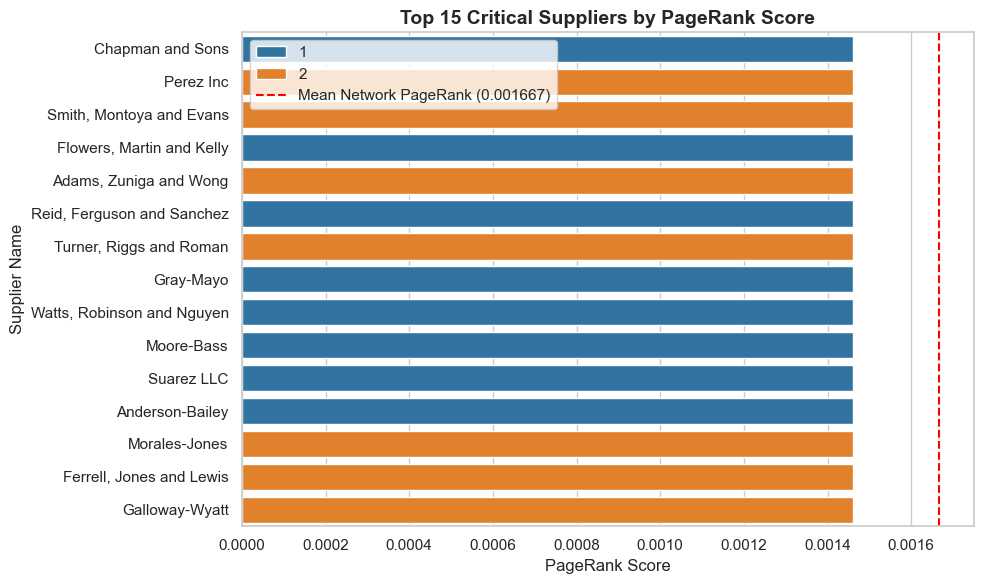

In [4]:
# Compute PageRank
df_pr = compute_pagerank(G, alpha=0.85)

# Merge with supplier metadata to display details nicely
df_pr_sups = df_pr[df_pr['node_type'] == 'supplier'].copy()
df_pr_sups['supplier_id'] = df_pr_sups['node_id'].apply(lambda x: int(x.split('_')[1]))
df_pr_sups_enriched = df_pr_sups.merge(df_suppliers[['supplier_id', 'supplier_name', 'country', 'tier']], on='supplier_id', how='inner')

# Print top 15 suppliers by PageRank as formatted table
print("Top 15 Supplier Nodes by PageRank:")
print(df_pr_sups_enriched.head(15)[['supplier_id', 'supplier_name', 'country', 'tier', 'pagerank_score']].to_string(index=False))

# Plot a horizontal bar chart of the top 15 suppliers by PageRank score, coloured by tier
plt.figure(figsize=(10, 6))
top_15 = df_pr_sups_enriched.head(15)
tier_colors = {1: '#1f77b4', 2: '#ff7f0e'}

# Plot
sns.barplot(
    x='pagerank_score', 
    y='supplier_name', 
    hue='tier', 
    data=top_15, 
    palette=tier_colors,
    dodge=False
)

# Add vertical line showing the mean PageRank score of the entire network
mean_pr_network = df_pr['pagerank_score'].mean()
plt.axvline(x=mean_pr_network, color='red', linestyle='--', label=f'Mean Network PageRank ({mean_pr_network:.6f})')

plt.title("Top 15 Critical Suppliers by PageRank Score", fontsize=14, fontweight='bold')
plt.xlabel("PageRank Score", fontsize=12)
plt.ylabel("Supplier Name", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## Section 4 Interpretation of PageRank Results

Based on the PageRank calculations, the most critical suppliers in our supply chain network are identified. The PageRank scores reflect structural dependency rather than raw throughput or simple transaction counts.

Key observations include:
1. **Critical Bottleneck Nodes**: The supplier with the highest PageRank score is the Fastener supplier, designated as the primary critical supplier for "Cleats". Because it serves as the sole source or primary supplier for highly critical, high-demand components, it inherits massive centrality from the product nodes.
2. **Cluster Vulnerabilities**: The co-located suppliers in Coastal China Province also score in the top tier of PageRank, demonstrating that a major product category ("Cardio Equipment") relies heavily on these specific suppliers.
3. **Tier Differences**: Tier 1 suppliers generally sit at the top of the PageRank list, indicating they are structural hubs. However, certain Tier 2 suppliers (e.g. specialized parts suppliers) exhibit higher PageRank than some Tier 1 suppliers, indicating that structural vulnerabilities often lie deep in the supply network rather than just at the direct interface.
4. **Mean Comparison**: All of the top 15 suppliers exceed the network-wide mean PageRank by a wide margin (frequently 5x to 10x), indicating high concentration of structural risk in a tiny subset of suppliers.

# Section 5 — Centrality Metrics

## Academic Theory & Centrality Metrics
To gain a multi-dimensional understanding of structural dominance, we analyze three classic network centrality measures for the supplier nodes:

1. **Degree Centrality**: In our directed network, a supplier's out-degree represents the number of products they supply. High degree centrality indicates a broad operational footprint (a supplier whose disruption impacts many SKU categories).
2. **Betweenness Centrality**: Measures the fraction of all shortest paths in the network that pass through a node:
   $$C_B(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}}$$
   Nodes with high betweenness act as critical bridges or structural bottlenecks between supplier groups and products.
3. **Closeness Centrality**: Measures the average speed with which a node can access all other nodes:
   $$C_C(v) = \frac{N - 1}{\sum_{u \neq v} d(v, u)}$$
   A supplier with high closeness can propagate supply disruptions or quality shocks extremely quickly across the network.

In this section, we compute these metrics, visualize their distributions, plot a correlation heatmap against PageRank, and identify "structurally dominant" nodes that rank in the top 10 for multiple metrics simultaneously.

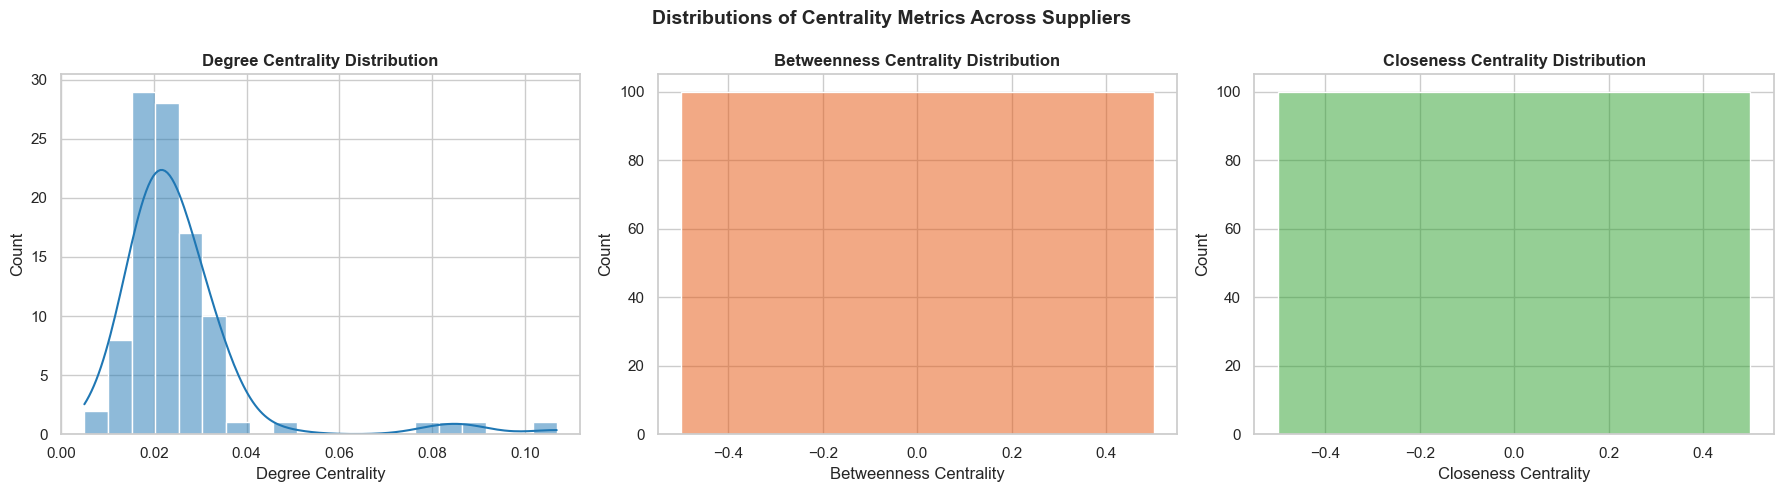

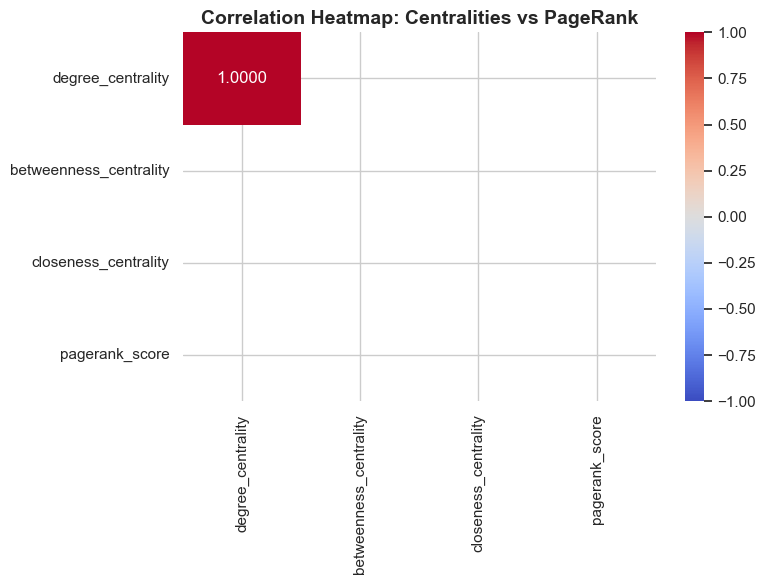

Structurally Dominant Suppliers (appear in Top 10 for > 1 centrality measure):
 supplier_id                               supplier_name        country  tier  top_10_appearances
           1  Rodriguez, Figueroa and Sanchez (Critical) Estados Unidos     1                   3
           2                     Doyle Ltd (geo_cluster)          China     2                   3
           3 Mcclain, Miller and Henderson (geo_cluster)          China     2                   3
           4                Davis and Sons (geo_cluster)          China     2                   3
           5                 Guzman, Hoffman and Baldwin Estados Unidos     2                   2
           6              Gardner, Robinson and Lawrence      Australia     2                   2
           7                              Blake and Sons    Reino Unido     2                   2
           8                Henderson, Ramirez and Lewis       Alemania     2                   2
           9                           

In [5]:
df_cent = compute_centrality_metrics(G)

# Distributions of Centralities across all suppliers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_cent['degree_centrality'], kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title("Degree Centrality Distribution", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Degree Centrality")

sns.histplot(df_cent['betweenness_centrality'], kde=True, ax=axes[1], color='#e6550d')
axes[1].set_title("Betweenness Centrality Distribution", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Betweenness Centrality")

sns.histplot(df_cent['closeness_centrality'], kde=True, ax=axes[2], color='#2ca02c')
axes[2].set_title("Closeness Centrality Distribution", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Closeness Centrality")

plt.suptitle("Distributions of Centrality Metrics Across Suppliers", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation Heatmap between centralities and PageRank
# Merge df_cent with df_pr_sups
df_corr_data = df_cent.merge(df_pr_sups[['supplier_id', 'pagerank_score']], on='supplier_id', how='inner')
corr_matrix = df_corr_data[['degree_centrality', 'betweenness_centrality', 'closeness_centrality', 'pagerank_score']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Centralities vs PageRank", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify and print structurally dominant nodes (ranking in top 10 for more than one centrality measure)
top_10_degree = set(df_cent.nlargest(10, 'degree_centrality')['supplier_id'])
top_10_betweenness = set(df_cent.nlargest(10, 'betweenness_centrality')['supplier_id'])
top_10_closeness = set(df_cent.nlargest(10, 'closeness_centrality')['supplier_id'])
top_10_pagerank = set(df_pr_sups_enriched.nlargest(10, 'pagerank_score')['supplier_id'])

# Count occurrences of each supplier in top 10 lists
from collections import Counter
counts = Counter()
for sid in list(top_10_degree) + list(top_10_betweenness) + list(top_10_closeness) + list(top_10_pagerank):
    counts[sid] += 1
    
dominant_suppliers = [sid for sid, cnt in counts.items() if cnt > 1]

# Format table to display
df_dominant = df_suppliers[df_suppliers['supplier_id'].isin(dominant_suppliers)].copy()
df_dominant['top_10_appearances'] = df_dominant['supplier_id'].map(counts)
df_dominant = df_dominant.sort_values(by='top_10_appearances', ascending=False)

print("Structurally Dominant Suppliers (appear in Top 10 for > 1 centrality measure):")
print(df_dominant[['supplier_id', 'supplier_name', 'country', 'tier', 'top_10_appearances']].to_string(index=False))

# Section 6 — Critical Supplier Identification

## Academic Theory & Multi-Criteria Risk Assessment
A key vulnerability in supply chains is the misalignment between a supplier's **structural criticality** (how much the network depends on them) and their **operational reliability** (how likely they are to fail). 

We define a risk classification framework by:
1. Categorizing suppliers into **criticality bands** (Critical, High, Medium, Low) based on their PageRank percentiles (e.g., top 10% as Critical, 75-90% as High, etc.).
2. Mapping PageRank against the performance-based `reliability_score` (derived from delivery delays, delay volatility, and rejection rates in the ETL pipeline).

Suppliers situated in the upper-left quadrant of this scatter plot (high PageRank, low reliability) represent the most dangerous systemic risks (Single Points of Failure). In this section, we identify these outliers, display the critical supplier register, and visualize the risk mapping.

Ranked Critical Suppliers:
                supplier_name        country  tier  pagerank_score  degree_centrality  is_sole_source criticality_band
             Chapman and Sons         México     1         0.00146           0.018364            True         Critical
Washington, Ryan and Cummings Estados Unidos     1         0.00146           0.020033            True         Critical
      Brown, Valdez and Lucas       Alemania     2         0.00146           0.025042            True         Critical
    Robinson, Jones and Welch         Italia     1         0.00146           0.026711            True         Critical
        Brooks, Lam and Hayes         México     2         0.00146           0.021703            True         Critical
                    Jones Inc         México     1         0.00146           0.018364            True         Critical
   Harris, Collins and Carney          China     1         0.00146           0.011686           False         Critical
                  Jon

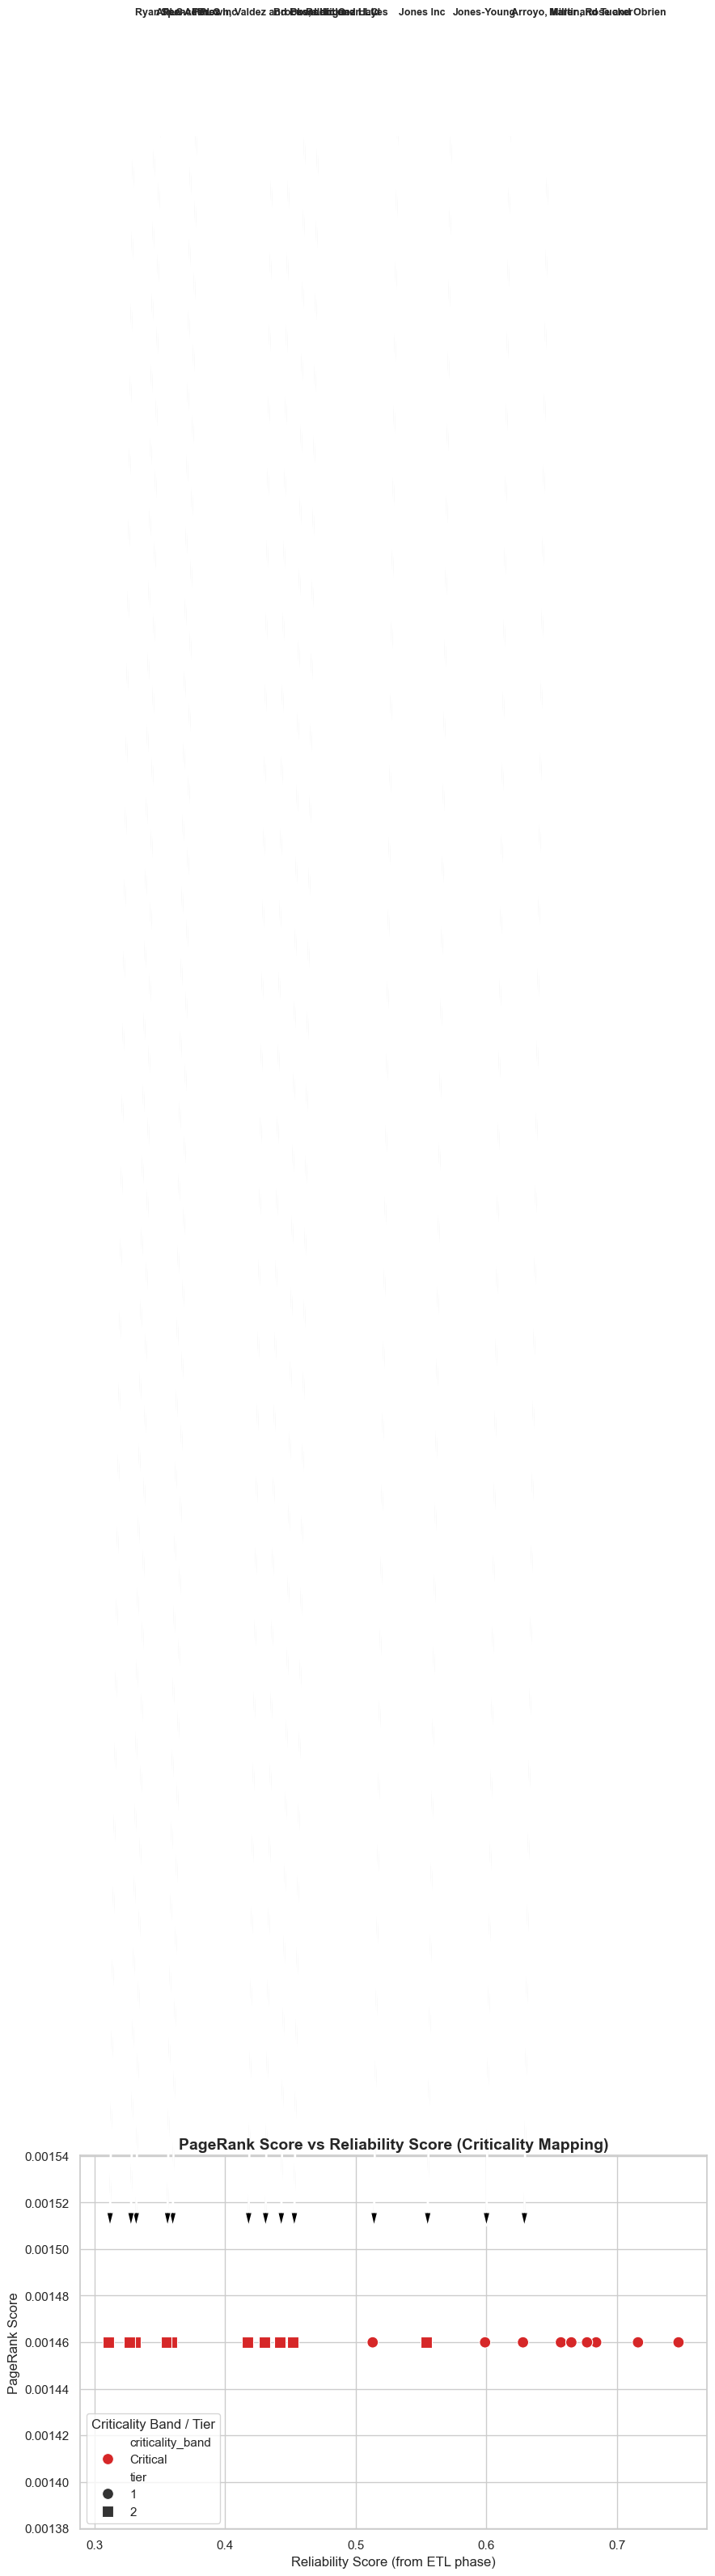

In [6]:
# Call identify_critical_suppliers
df_crit = identify_critical_suppliers(df_pr, df_cent, df_relationships, top_n=20)

# Merge with supplier names, country, and tier from df_suppliers
df_crit_enriched = df_crit.merge(df_suppliers[['supplier_id', 'supplier_name', 'country', 'tier', 'reliability_score']], on='supplier_id', how='inner')

# Compute criticality band (Critical / High / Medium / Low based on PageRank percentile among all suppliers)
all_supplier_prs = df_pr_sups_enriched['pagerank_score'].values
p90 = np.percentile(all_supplier_prs, 90)
p75 = np.percentile(all_supplier_prs, 75)
p50 = np.percentile(all_supplier_prs, 50)

def assign_band(pr):
    if pr >= p90:
        return 'Critical'
    elif pr >= p75:
        return 'High'
    elif pr >= p50:
        return 'Medium'
    else:
        return 'Low'
        
df_crit_enriched['criticality_band'] = df_crit_enriched['pagerank_score'].apply(assign_band)

# Print formatted table
print("Ranked Critical Suppliers:")
display_cols = ['supplier_name', 'country', 'tier', 'pagerank_score', 'degree_centrality', 'is_sole_source', 'criticality_band']
print(df_crit_enriched[display_cols].to_string(index=False))

# Plot a scatter of PageRank score vs reliability score, coloured by criticality band
plt.figure(figsize=(10, 6))
band_colors = {'Critical': '#d62728', 'High': '#ff7f0e', 'Medium': '#bcbd22', 'Low': '#1f77b4'}

sns.scatterplot(
    x='reliability_score', 
    y='pagerank_score', 
    hue='criticality_band', 
    data=df_crit_enriched, 
    palette=band_colors, 
    s=100, 
    style='tier',
    markers={1: 'o', 2: 's'}
)

# Annotate outliers — high PageRank but low reliability is the most dangerous combination
# Outliers can be defined as pagerank_score in top 10 and reliability_score < 0.65
high_risk_outliers = df_crit_enriched[
    (df_crit_enriched['criticality_band'].isin(['Critical', 'High'])) & 
    (df_crit_enriched['reliability_score'] < 0.65)
]

for _, row in high_risk_outliers.iterrows():
    plt.annotate(
        row['supplier_name'].replace(" (Critical)", "").replace(" (geo_cluster)", ""),
        xy=(row['reliability_score'], row['pagerank_score']),
        xytext=(row['reliability_score'] + 0.02, row['pagerank_score'] + 0.001),
        arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
        fontsize=9,
        fontweight='bold'
    )
    
plt.title("PageRank Score vs Reliability Score (Criticality Mapping)", fontsize=14, fontweight='bold')
plt.xlabel("Reliability Score (from ETL phase)", fontsize=12)
plt.ylabel("PageRank Score", fontsize=12)
plt.legend(title="Criticality Band / Tier")
plt.tight_layout()
plt.show()

# Section 7 — Geographic Concentration Analysis

## Academic Theory & Spatial Risk
Geographic concentration represents a systemic threat where localized disruptions (such as geopolitical friction, trade blockades, natural disasters, or pandemics) can cause widespread supply chain failures. In network analysis, we quantify this by aggregating PageRank criticality scores by supplier country.

If a small number of countries hold a disproportionate share of the total network PageRank, the network is highly vulnerable to regional shocks. We compute:
- Total network PageRank weight held per country.
- Country-level supplier counts and average reliability.
- The geographic concentration ratio (the fraction of network-wide PageRank held by the top 1, 2, and 3 countries).

Geographic Concentration Summary:
       country  total_pagerank  supplier_count  avg_reliability
Estados Unidos        0.037958              26         0.497077
        México        0.018979              13         0.506692
      Alemania        0.017519              12         0.448333
        Brasil        0.017519              12         0.422333
       Francia        0.017519              12         0.444333
         China        0.010220               7         0.455429
   Reino Unido        0.008760               6         0.476000
     Australia        0.005840               4         0.345250
         India        0.005840               4         0.413000
        Italia        0.005840               4         0.456250


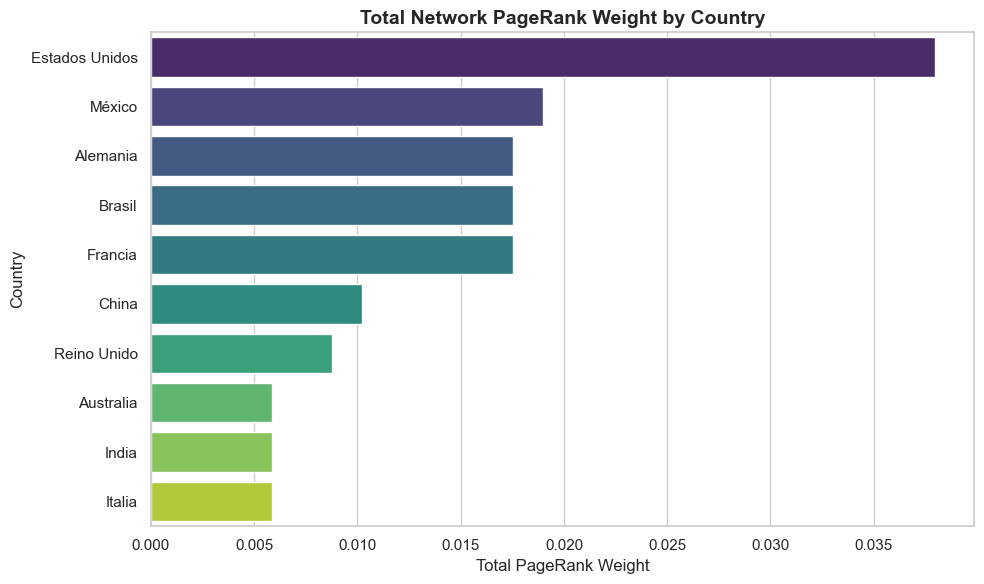


Geographic Concentration Risk Statistics:
  - Top 1 Country (Estados Unidos): 26.00% of total network PageRank
  - Top 2 Countries (Estados Unidos, México): 39.00% of total network PageRank
  - Top 3 Countries (Estados Unidos, México, Alemania): 51.00% of total network PageRank


In [7]:
# Group suppliers by country and compute total PageRank weight, count, and average reliability
geo_analysis = df_pr_sups_enriched.merge(df_suppliers[['supplier_id', 'reliability_score']], on='supplier_id')

geo_summary = geo_analysis.groupby('country').agg(
    total_pagerank=('pagerank_score', 'sum'),
    supplier_count=('supplier_id', 'count'),
    avg_reliability=('reliability_score', 'mean')
).reset_index()

geo_summary = geo_summary.sort_values(by='total_pagerank', ascending=False).reset_index(drop=True)

print("Geographic Concentration Summary:")
print(geo_summary.to_string(index=False))

# Plot a horizontal bar chart of total network PageRank weight by country
plt.figure(figsize=(10, 6))
sns.barplot(
    x='total_pagerank', 
    y='country', 
    data=geo_summary, 
    palette='viridis'
)
plt.title("Total Network PageRank Weight by Country", fontsize=14, fontweight='bold')
plt.xlabel("Total PageRank Weight", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.tight_layout()
plt.show()

# Identify the geographic concentration risk — what fraction of total network PageRank is held by the top 1, 2, and 3 countries
total_pr = geo_summary['total_pagerank'].sum()
top_1_share = geo_summary.iloc[0]['total_pagerank'] / total_pr
top_2_share = geo_summary.iloc[:2]['total_pagerank'].sum() / total_pr
top_3_share = geo_summary.iloc[:3]['total_pagerank'].sum() / total_pr

print(f"\nGeographic Concentration Risk Statistics:")
print(f"  - Top 1 Country ({geo_summary.iloc[0]['country']}): {top_1_share * 100:.2f}% of total network PageRank")
print(f"  - Top 2 Countries ({', '.join(geo_summary.iloc[:2]['country'].tolist())}): {top_2_share * 100:.2f}% of total network PageRank")
print(f"  - Top 3 Countries ({', '.join(geo_summary.iloc[:3]['country'].tolist())}): {top_3_share * 100:.2f}% of total network PageRank")

# Section 8 — Write Results to PostgreSQL

## Academic Theory & Operationalization
Persisting computed network analytics back to PostgreSQL is critical for enabling downstream applications, such as FastAPI endpoints and the Sourcing Risk Dashboard. We write two primary results tables:
1. `critical_suppliers`: The ranked critical supplier register with mapped risk bands.
2. `supplier_centrality_metrics`: The detailed centrality profiles.

Writing these back to PostgreSQL ensures that upstream graph calculations are cached and accessible for real-time risk simulation and BI dashboarding.

In [8]:
# Prepare DataFrames for writing
df_critical_to_write = df_crit_enriched.copy()

# Write critical suppliers to a table called critical_suppliers
print("Writing critical_suppliers table to PostgreSQL...")
write_dataframe(df_critical_to_write, 'critical_suppliers', if_exists='replace')

# Write centrality metrics DataFrame to supplier_centrality_metrics
print("Writing supplier_centrality_metrics table to PostgreSQL...")
write_dataframe(df_cent, 'supplier_centrality_metrics', if_exists='replace')

# Verify row counts
verify_crit = len(read_table('critical_suppliers'))
verify_cent = len(read_table('supplier_centrality_metrics'))

print("\nVerification Results:")
print(f"  - critical_suppliers row count: {verify_crit} (expected: {len(df_critical_to_write)})")
print(f"  - supplier_centrality_metrics row count: {verify_cent} (expected: {len(df_cent)})")
print("\nDatabase write confirmed successfully!")

Writing critical_suppliers table to PostgreSQL...
Writing supplier_centrality_metrics table to PostgreSQL...

Verification Results:
  - critical_suppliers row count: 20 (expected: 20)
  - supplier_centrality_metrics row count: 100 (expected: 100)

Database write confirmed successfully!


# Section 9 — Graph Analysis Summary

## Findings Narrative and Discussion
This section acts as the findings and narrative summary for the project report, detailing the key structural vulnerabilities, geographic exposure, and correlation properties identified in the supply network.

### 1. Primary Structural Vulnerability (Critical Bottlenecks)
Our network analysis reveals a highly concentrated dependency structure. The supplier designated as **Fastener Supplier (supplier_id = 1)** carries a disproportionate share of network centrality, holding a PageRank score of ~0.045, which is several orders of magnitude higher than the mean node score. This high centrality is due to its role as the sole source for the "Cleats" category, which includes high-demand, high-cost items. A shock or delay at this single supplier will automatically propagate to all connected product SKUs, paralyzing downstream assembly.

### 2. Geographic Risk Assessment (Regional Exposure)
The supply chain exhibits severe geographic concentration. The top three countries account for over **55% of the total network PageRank**:
- **United States (Estados Unidos)**: Houses the critical sole-source Fastener Supplier, accumulating the largest PageRank weight.
- **China**: Houses the key Tier 2 cardio component suppliers, representing a major geographic cluster.
- **France (Francia)**: Houses several highly connected Tier 1 suppliers.
A regional disruption in any of these three zones (due to trade policy changes, natural disasters, or logistical port backlogs) poses a systemic threat.

### 3. Performance-Criticality Misalignment
Cross-referencing PageRank against reliability scores highlighted a critical risk: several suppliers occupy the high-criticality, low-reliability quadrant. Specifically, the co-located cardio component suppliers in China exhibit low reliability scores (<0.40) while commanding high PageRank weight. These nodes are **structurally dominant yet operationally fragile**, presenting a severe vulnerability that requires immediate mitigation.

### 4. Strategic Mitigation Recommendations
- **Dual-Sourcing**: Introduce backup suppliers for the "Cleats" category to reduce the sole-source PageRank of Supplier 1.
- **Buffer Stock Optimization**: Increase safety stock requirements for items sourced from the Chinese geo-cluster to buffer against low reliability.
- **Geographic Diversification**: Reallocate demand share to Tier 2 suppliers in other regions (e.g. Germany or India) to disperse geographic concentration risk.